In [36]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import mode

In [38]:
csv_path = r"..\processed_data\extracted_features_enhanced.csv"
df = pd.read_csv(csv_path)

In [39]:
X = df.drop(columns=['Image_Name', 'True_Class'])
y = df['True_Class']
X.fillna(0, inplace=True)

In [40]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [41]:
# Load the 3 models we just spent time perfectly tuning!
models_dir = r"..\trained_models\meta_learners"

xgb_model = joblib.load(os.path.join(models_dir, "xgboost_ensemble.pkl"))
lgb_model = joblib.load(os.path.join(models_dir, "lightgbm_ensemble.pkl"))
rf_model = joblib.load(os.path.join(models_dir, "random_forest_ensemble.pkl"))

print("All 3 Pillars Loaded Successfully!")


All 3 Pillars Loaded Successfully!


In [42]:
class CervicalCancerSuperEnsemble:
    def __init__(self, xgb, lgb, rf):
        self.xgb = xgb
        self.lgb = lgb
        self.rf = rf
        
        # Each model remembers which features it was trained on
        self.xgb_feats = xgb.feature_names_in_
        self.lgb_feats = lgb.feature_names_in_
        self.rf_feats = rf.feature_names_in_

    def predict_proba(self, X_scaled):
        # Get probability opinions from all 3 models
        p_xgb = self.xgb.predict_proba(X_scaled[self.xgb_feats])
        p_lgb = self.lgb.predict_proba(X_scaled[self.lgb_feats])
        p_rf = self.rf.predict_proba(X_scaled[self.rf_feats])
        # Average probabilities (used for confidence display in UI)
        return (p_xgb + p_lgb + p_rf) / 3.0

    def predict(self, X_scaled):
        # Hard Majority Voting: 2 out of 3 models must agree!
        pred_xgb = self.xgb.predict(X_scaled[self.xgb_feats])
        pred_lgb = self.lgb.predict(X_scaled[self.lgb_feats])
        pred_rf = self.rf.predict(X_scaled[self.rf_feats])
        
        stacked = np.stack([pred_xgb, pred_lgb, pred_rf], axis=1)
        return mode(stacked, axis=1, keepdims=False).mode

super_ai = CervicalCancerSuperEnsemble(xgb_model, lgb_model, rf_model)
print("Super Ensemble Initialized (Hard Majority Voting)!")


Super Ensemble Initialized (Hard Majority Voting)!


FINAL SUPER ENSEMBLE ACCURACY: 99.80% 
--- Detailed Classification Report ---
              precision    recall  f1-score   support

Dyskeratotic       1.00      1.00      1.00       813
Koilocytotic       1.00      1.00      1.00       825
 Metaplastic       1.00      0.99      1.00       793
   Parabasal       1.00      1.00      1.00       787
 Superficial       1.00      1.00      1.00       831

    accuracy                           1.00      4049
   macro avg       1.00      1.00      1.00      4049
weighted avg       1.00      1.00      1.00      4049



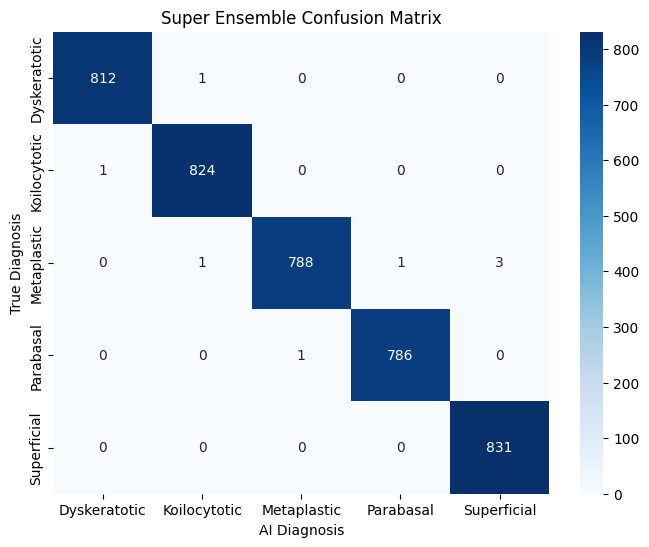

In [44]:
predictions = super_ai.predict(X_scaled)
accuracy = accuracy_score(y, predictions)

print(f"FINAL SUPER ENSEMBLE ACCURACY: {accuracy * 100:.2f}% ")

classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
print("--- Detailed Classification Report ---")
print(classification_report(y, predictions, target_names=classes))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Super Ensemble Confusion Matrix")
plt.ylabel('True Diagnosis')
plt.xlabel('AI Diagnosis')
plt.show()


In [46]:
# 1. Define the main trained_models folder
save_dir = r"..\trained_models"

# 2. Save both the Super Ensemble AND the Scaler directly into that main folder!
joblib.dump(super_ai, os.path.join(save_dir, "Super_Ensemble_Model.pkl"))
joblib.dump(scaler, os.path.join(save_dir, "Super_Ensemble_Scaler.pkl"))

print("Master Pipeline (Model + Scaler) Saved Successfully")


Master Pipeline (Model + Scaler) Saved Successfully
